# Annual NetCDFs: Per Lat Batching

Example processing annual NetCDFs, meaning all days of the year for a given measure consolidated in each file. Each file is 233MB from CMIP6. This notebook processes the moderate models for 2025 and 20250 for surface air temperature variable 'tasmax'.

> CMIP6 ssp245 tasmax is a dataset that provides projections of the annual maximum near-surface air temperature for the SSP245 [moderate] scenario. The SSP245 scenario is part of the Coupled Model Intercomparison Project Phase 6 (CMIP6). [[1](https://earth.gov/data-catalog/cmip6-climdex-tasmax-yearly-median)]

![](https://earth.gov/relief_monthly_max_ssp126.5e5726f6.png)

__Configuration__

1. Run on a r6id.2xlarge cluster with 4 workers (total 32 cores / 256GB).
1. DBR 15.4 LTS Dedicated (vs Standard) cluster used.
1. Since we are turning off AQE during the operations and not using any product built-in spatial sql or h3 expressions, can run w/o Photon.
1. Given the size and nested nature of the files, we are going to use netcdf slices to read.

__Findings__

> The price you pay to extract lat/lon pairs individually from a netCDF with xarray is really high. So, doing each lat with all lon pairs together as a chunk gives us very reasonable / good performance. 

__Each 233MB annual file can be processed into Delta Lake in around 0.5 DBU with this approach;__ also, CSVs stored for each year takes ~1.1GB (4x the original netCDF).

* This is for the whole 233MB netCDF (860K rows generated).
* DBU estimate then is 3 * 10 DBU/60 = 0.5 DBUs per file to get to initial delta lake.

---
__Author:__ Michael Johns <mjohns@databricks.com> | _Last Modified: 06 FEB 2025_

## Imports & Config

In [0]:
%run ./netcdf_helpers.py

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%sql
-- adjust to your needs
use catalog geospatial_docs;
use schema large_netcdf;

## Data

> Adjust paths as-needed; the volume dirs are expected to already exits.

In [0]:
import os

filename_2025 = "tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2025.nc"
vol_dir = "/Volumes/geospatial_docs/large_netcdf/data"
vol_dir_out = '/Volumes/geospatial_docs/large_netcdf/out_data'

os.environ['FILENAME_2025'] = filename_2025
os.environ['VOL_DIR'] = vol_dir
os.environ['VOL_DIR_OUT'] = vol_dir_out

In [0]:
%sh
wget -P $VOL_DIR -nc https://nex-gddp-cmip6.s3-us-west-2.amazonaws.com/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/tasmax/$FILENAME_2025

ls -lh $VOL_DIR

File ‘/Volumes/geospatial_docs/large_netcdf/data/tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2025.nc’ already there; not retrieving.



total 466M
-rwxrwxrwx 1 nobody nogroup 233M Oct 12 14:04 tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2025.nc
-rwxrwxrwx 1 nobody nogroup 233M Feb  7 12:21 tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2050.nc


True


## Test a single Lat Value

> Handles a slice for each lat over the year. __Note: this is a single node.__

In [0]:
%sh rm -rf $VOL_DIR_OUT/slice_test

In [0]:
process_slice(
  xr.open_dataset(f'{vol_dir}/{filename_2025}'),
  'tasmax', 0, save_dir=f'{vol_dir_out}/slice_test'
)

'/Volumes/geospatial_docs/large_netcdf/out_data/slice_test/tasmax_lat_0.csv'

In [0]:
ls -lh $VOL_DIR_OUT/slice_test

total 555K
-rwxrwxrwx 1 nobody nogroup 555K Feb  7 14:31 tasmax_lat_0.csv*


__Test loading the CSV as Spark DataFrame__

> Uses specified CSV Schema in later functions as well.

In [0]:
df_csv = (
  spark
    .read
    .csv(f"{vol_dir_out}/slice_test", header=True, schema=csv_schema)
  .na.fill(0.0)
)
print(f"count? {df_csv.count():,}")
print(f"count non-null? {df_csv.dropna().count():,}")
df_csv.limit(1).display()

count? 1,439
count non-null? 1,439


data_var,year,lat,lon,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31,day_32,day_33,day_34,day_35,day_36,day_37,day_38,day_39,day_40,day_41,day_42,day_43,day_44,day_45,day_46,day_47,day_48,day_49,day_50,day_51,day_52,day_53,day_54,day_55,day_56,day_57,day_58,day_59,day_60,day_61,day_62,day_63,day_64,day_65,day_66,day_67,day_68,day_69,day_70,day_71,day_72,day_73,day_74,day_75,day_76,day_77,day_78,day_79,day_80,day_81,day_82,day_83,day_84,day_85,day_86,day_87,day_88,day_89,day_90,day_91,day_92,day_93,day_94,day_95,day_96,day_97,day_98,day_99,day_100,day_101,day_102,day_103,day_104,day_105,day_106,day_107,day_108,day_109,day_110,day_111,day_112,day_113,day_114,day_115,day_116,day_117,day_118,day_119,day_120,day_121,day_122,day_123,day_124,day_125,day_126,day_127,day_128,day_129,day_130,day_131,day_132,day_133,day_134,day_135,day_136,day_137,day_138,day_139,day_140,day_141,day_142,day_143,day_144,day_145,day_146,day_147,day_148,day_149,day_150,day_151,day_152,day_153,day_154,day_155,day_156,day_157,day_158,day_159,day_160,day_161,day_162,day_163,day_164,day_165,day_166,day_167,day_168,day_169,day_170,day_171,day_172,day_173,day_174,day_175,day_176,day_177,day_178,day_179,day_180,day_181,day_182,day_183,day_184,day_185,day_186,day_187,day_188,day_189,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199,day_200,day_201,day_202,day_203,day_204,day_205,day_206,day_207,day_208,day_209,day_210,day_211,day_212,day_213,day_214,day_215,day_216,day_217,day_218,day_219,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229,day_230,day_231,day_232,day_233,day_234,day_235,day_236,day_237,day_238,day_239,day_240,day_241,day_242,day_243,day_244,day_245,day_246,day_247,day_248,day_249,day_250,day_251,day_252,day_253,day_254,day_255,day_256,day_257,day_258,day_259,day_260,day_261,day_262,day_263,day_264,day_265,day_266,day_267,day_268,day_269,day_270,day_271,day_272,day_273,day_274,day_275,day_276,day_277,day_278,day_279,day_280,day_281,day_282,day_283,day_284,day_285,day_286,day_287,day_288,day_289,day_290,day_291,day_292,day_293,day_294,day_295,day_296,day_297,day_298,day_299,day_300,day_301,day_302,day_303,day_304,day_305,day_306,day_307,day_308,day_309,day_310,day_311,day_312,day_313,day_314,day_315,day_316,day_317,day_318,day_319,day_320,day_321,day_322,day_323,day_324,day_325,day_326,day_327,day_328,day_329,day_330,day_331,day_332,day_333,day_334,day_335,day_336,day_337,day_338,day_339,day_340,day_341,day_342,day_343,day_344,day_345,day_346,day_347,day_348,day_349,day_350,day_351,day_352,day_353,day_354,day_355,day_356,day_357,day_358,day_359,day_360,day_361,day_362,day_363,day_364,day_365
tasmax,2025,-59.875,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

## Create Pandas UDF

> Want a (vectorized) pandas UDF to manage chunks (slices) of lat / lon values over the year.

In [0]:
df_meta = (
  spark
    .createDataFrame(
      [(
        f'{vol_dir}/{filename_2025}',
        'tasmax', 0, vol_dir_out
      ),],
      ["vol_path", "data_var", "lat_idx", 'vol_dir_out']
    )
)
df_meta.display()

vol_path,data_var,lat_idx,vol_dir_out
/Volumes/geospatial_docs/large_netcdf/data/tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2025.nc,tasmax,0,/Volumes/geospatial_docs/large_netcdf/out_data


### Test with 1 batch (1 lat)

> Note: this will load all files under `<vol_dir_out>/<filename>` dir, so may have more than 1 lat in table (if re-executed).

In [0]:
df_b1 = process_annual(
  f'{vol_dir}/{filename_2025}', 'tasmax', 'xy_pred_annual', vol_dir_out,
  drop_table=True, skip_table=False, batch_limit=1, debug_mode=1
)

... n_lat: 600
... limit provided -> # batches? 1
... total batches estimated: 1
... finished batch(es) per lat
... create or replace table: xy_pred_annual
... rows in table? 863,400


data_var,year,lat,lon,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31,day_32,day_33,day_34,day_35,day_36,day_37,day_38,day_39,day_40,day_41,day_42,day_43,day_44,day_45,day_46,day_47,day_48,day_49,day_50,day_51,day_52,day_53,day_54,day_55,day_56,day_57,day_58,day_59,day_60,day_61,day_62,day_63,day_64,day_65,day_66,day_67,day_68,day_69,day_70,day_71,day_72,day_73,day_74,day_75,day_76,day_77,day_78,day_79,day_80,day_81,day_82,day_83,day_84,day_85,day_86,day_87,day_88,day_89,day_90,day_91,day_92,day_93,day_94,day_95,day_96,day_97,day_98,day_99,day_100,day_101,day_102,day_103,day_104,day_105,day_106,day_107,day_108,day_109,day_110,day_111,day_112,day_113,day_114,day_115,day_116,day_117,day_118,day_119,day_120,day_121,day_122,day_123,day_124,day_125,day_126,day_127,day_128,day_129,day_130,day_131,day_132,day_133,day_134,day_135,day_136,day_137,day_138,day_139,day_140,day_141,day_142,day_143,day_144,day_145,day_146,day_147,day_148,day_149,day_150,day_151,day_152,day_153,day_154,day_155,day_156,day_157,day_158,day_159,day_160,day_161,day_162,day_163,day_164,day_165,day_166,day_167,day_168,day_169,day_170,day_171,day_172,day_173,day_174,day_175,day_176,day_177,day_178,day_179,day_180,day_181,day_182,day_183,day_184,day_185,day_186,day_187,day_188,day_189,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199,day_200,day_201,day_202,day_203,day_204,day_205,day_206,day_207,day_208,day_209,day_210,day_211,day_212,day_213,day_214,day_215,day_216,day_217,day_218,day_219,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229,day_230,day_231,day_232,day_233,day_234,day_235,day_236,day_237,day_238,day_239,day_240,day_241,day_242,day_243,day_244,day_245,day_246,day_247,day_248,day_249,day_250,day_251,day_252,day_253,day_254,day_255,day_256,day_257,day_258,day_259,day_260,day_261,day_262,day_263,day_264,day_265,day_266,day_267,day_268,day_269,day_270,day_271,day_272,day_273,day_274,day_275,day_276,day_277,day_278,day_279,day_280,day_281,day_282,day_283,day_284,day_285,day_286,day_287,day_288,day_289,day_290,day_291,day_292,day_293,day_294,day_295,day_296,day_297,day_298,day_299,day_300,day_301,day_302,day_303,day_304,day_305,day_306,day_307,day_308,day_309,day_310,day_311,day_312,day_313,day_314,day_315,day_316,day_317,day_318,day_319,day_320,day_321,day_322,day_323,day_324,day_325,day_326,day_327,day_328,day_329,day_330,day_331,day_332,day_333,day_334,day_335,day_336,day_337,day_338,day_339,day_340,day_341,day_342,day_343,day_344,day_345,day_346,day_347,day_348,day_349,day_350,day_351,day_352,day_353,day_354,day_355,day_356,day_357,day_358,day_359,day_360,day_361,day_362,day_363,day_364,day_365
tasmax,2025,-59.875,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

_With `skip_table` True shown below (files already processed, so very fast)._

In [0]:
process_annual(
  f'{vol_dir}/{filename_2025}',
  'tasmax', 'xy_pred_annual', vol_dir_out, skip_table=True, batch_limit=1, debug_mode=1
)

... n_lat: 600
... limit provided -> # batches? 1
... total batches estimated: 1
... finished batch(es) per lat
... skip_table provided


### Test with 100 batches

In [0]:
%sh
# optionally empty dir to time
# rm -rf $VOL_DIR_OUT/$FILENAME_2025
# ls -lh $VOL_DIR_OUT/$FILENAME_2025

In [0]:
df_b100 = process_annual(
  f'{vol_dir}/{filename_2025}',
  'tasmax', 'xy_pred_annual', vol_dir_out, drop_table=True, batch_limit=100, debug_mode=1
)

... n_lat: 600
... limit provided -> # batches? 100
... total batches estimated: 100
... finished batch(es) per lat
... create or replace table: xy_pred_annual
... rows in table? 863,400


data_var,year,lat,lon,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31,day_32,day_33,day_34,day_35,day_36,day_37,day_38,day_39,day_40,day_41,day_42,day_43,day_44,day_45,day_46,day_47,day_48,day_49,day_50,day_51,day_52,day_53,day_54,day_55,day_56,day_57,day_58,day_59,day_60,day_61,day_62,day_63,day_64,day_65,day_66,day_67,day_68,day_69,day_70,day_71,day_72,day_73,day_74,day_75,day_76,day_77,day_78,day_79,day_80,day_81,day_82,day_83,day_84,day_85,day_86,day_87,day_88,day_89,day_90,day_91,day_92,day_93,day_94,day_95,day_96,day_97,day_98,day_99,day_100,day_101,day_102,day_103,day_104,day_105,day_106,day_107,day_108,day_109,day_110,day_111,day_112,day_113,day_114,day_115,day_116,day_117,day_118,day_119,day_120,day_121,day_122,day_123,day_124,day_125,day_126,day_127,day_128,day_129,day_130,day_131,day_132,day_133,day_134,day_135,day_136,day_137,day_138,day_139,day_140,day_141,day_142,day_143,day_144,day_145,day_146,day_147,day_148,day_149,day_150,day_151,day_152,day_153,day_154,day_155,day_156,day_157,day_158,day_159,day_160,day_161,day_162,day_163,day_164,day_165,day_166,day_167,day_168,day_169,day_170,day_171,day_172,day_173,day_174,day_175,day_176,day_177,day_178,day_179,day_180,day_181,day_182,day_183,day_184,day_185,day_186,day_187,day_188,day_189,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199,day_200,day_201,day_202,day_203,day_204,day_205,day_206,day_207,day_208,day_209,day_210,day_211,day_212,day_213,day_214,day_215,day_216,day_217,day_218,day_219,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229,day_230,day_231,day_232,day_233,day_234,day_235,day_236,day_237,day_238,day_239,day_240,day_241,day_242,day_243,day_244,day_245,day_246,day_247,day_248,day_249,day_250,day_251,day_252,day_253,day_254,day_255,day_256,day_257,day_258,day_259,day_260,day_261,day_262,day_263,day_264,day_265,day_266,day_267,day_268,day_269,day_270,day_271,day_272,day_273,day_274,day_275,day_276,day_277,day_278,day_279,day_280,day_281,day_282,day_283,day_284,day_285,day_286,day_287,day_288,day_289,day_290,day_291,day_292,day_293,day_294,day_295,day_296,day_297,day_298,day_299,day_300,day_301,day_302,day_303,day_304,day_305,day_306,day_307,day_308,day_309,day_310,day_311,day_312,day_313,day_314,day_315,day_316,day_317,day_318,day_319,day_320,day_321,day_322,day_323,day_324,day_325,day_326,day_327,day_328,day_329,day_330,day_331,day_332,day_333,day_334,day_335,day_336,day_337,day_338,day_339,day_340,day_341,day_342,day_343,day_344,day_345,day_346,day_347,day_348,day_349,day_350,day_351,day_352,day_353,day_354,day_355,day_356,day_357,day_358,day_359,day_360,day_361,day_362,day_363,day_364,day_365
tasmax,2025,-59.875,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

### Test with All lats (600 batches)

- 32 cores over 4 workers took 3 minutes
- this is for the whole 233MB netCDF (860K rows generated)
- DBU estimate then is 3 * 10 DBU/60 = 0.5 DBUs per file to get to initial delta lake

In [0]:
%sh
# optionally empty dir to time
rm -rf $VOL_DIR_OUT/$FILENAME_2025
ls -lh $VOL_DIR_OUT/$FILENAME_2025

ls: cannot access '/Volumes/geospatial_docs/large_netcdf/out_data/tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2025.nc': No such file or directory


In [0]:
df_2025 = process_annual(
  f'{vol_dir}/{filename_2025}',
  'tasmax', 'xy_pred_annual', vol_dir_out, drop_table=True, debug_mode=1
)

... n_lat: 600
... total batches estimated: 600
... finished batch(es) per lat
... create or replace table: xy_pred_annual
... rows in table? 863,400


data_var,year,lat,lon,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31,day_32,day_33,day_34,day_35,day_36,day_37,day_38,day_39,day_40,day_41,day_42,day_43,day_44,day_45,day_46,day_47,day_48,day_49,day_50,day_51,day_52,day_53,day_54,day_55,day_56,day_57,day_58,day_59,day_60,day_61,day_62,day_63,day_64,day_65,day_66,day_67,day_68,day_69,day_70,day_71,day_72,day_73,day_74,day_75,day_76,day_77,day_78,day_79,day_80,day_81,day_82,day_83,day_84,day_85,day_86,day_87,day_88,day_89,day_90,day_91,day_92,day_93,day_94,day_95,day_96,day_97,day_98,day_99,day_100,day_101,day_102,day_103,day_104,day_105,day_106,day_107,day_108,day_109,day_110,day_111,day_112,day_113,day_114,day_115,day_116,day_117,day_118,day_119,day_120,day_121,day_122,day_123,day_124,day_125,day_126,day_127,day_128,day_129,day_130,day_131,day_132,day_133,day_134,day_135,day_136,day_137,day_138,day_139,day_140,day_141,day_142,day_143,day_144,day_145,day_146,day_147,day_148,day_149,day_150,day_151,day_152,day_153,day_154,day_155,day_156,day_157,day_158,day_159,day_160,day_161,day_162,day_163,day_164,day_165,day_166,day_167,day_168,day_169,day_170,day_171,day_172,day_173,day_174,day_175,day_176,day_177,day_178,day_179,day_180,day_181,day_182,day_183,day_184,day_185,day_186,day_187,day_188,day_189,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199,day_200,day_201,day_202,day_203,day_204,day_205,day_206,day_207,day_208,day_209,day_210,day_211,day_212,day_213,day_214,day_215,day_216,day_217,day_218,day_219,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229,day_230,day_231,day_232,day_233,day_234,day_235,day_236,day_237,day_238,day_239,day_240,day_241,day_242,day_243,day_244,day_245,day_246,day_247,day_248,day_249,day_250,day_251,day_252,day_253,day_254,day_255,day_256,day_257,day_258,day_259,day_260,day_261,day_262,day_263,day_264,day_265,day_266,day_267,day_268,day_269,day_270,day_271,day_272,day_273,day_274,day_275,day_276,day_277,day_278,day_279,day_280,day_281,day_282,day_283,day_284,day_285,day_286,day_287,day_288,day_289,day_290,day_291,day_292,day_293,day_294,day_295,day_296,day_297,day_298,day_299,day_300,day_301,day_302,day_303,day_304,day_305,day_306,day_307,day_308,day_309,day_310,day_311,day_312,day_313,day_314,day_315,day_316,day_317,day_318,day_319,day_320,day_321,day_322,day_323,day_324,day_325,day_326,day_327,day_328,day_329,day_330,day_331,day_332,day_333,day_334,day_335,day_336,day_337,day_338,day_339,day_340,day_341,day_342,day_343,day_344,day_345,day_346,day_347,day_348,day_349,day_350,day_351,day_352,day_353,day_354,day_355,day_356,day_357,day_358,day_359,day_360,day_361,day_362,day_363,day_364,day_365
tasmax,2025,-59.875,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [0]:
%sql describe detail xy_pred_annual

format,id,name,description,location,createdAt,lastModified,partitionColumns,clusteringColumns,numFiles,sizeInBytes,properties,minReaderVersion,minWriterVersion,tableFeatures,statistics
delta,ba9920c6-89ac-47e6-96f8-654844968a8e,geospatial_docs.large_netcdf.xy_pred_annual,null,s3://databricks-e2demofieldengwest/b169b504-4c54-49f2-bc3a-adf4b128f36d/tables/1868399d-5ac2-4417-9df2-61f7c7f6abb2,2025-02-07T14:34:59.189Z,2025-02-07T14:35:20Z,List(),List(),34,870725119,Map(delta.enableDeletionVectors -> true),3,7,List(deletionVectors),"Map(numRowsDeletedByDeletionVectors -> 0, numDeletionVectors -> 0)"


_So this annual file yielded 860K rows for each LAT/LONG pair with a column for each day of the year._

## Characterize the Annual Data

In [0]:
day_cols = []
for c in df_2025.columns:
  if c.startswith('day_'):
    day_cols.append(c)
# day_cols

In [0]:
df_agg_2025 = (
  df_2025
    .withColumn("all_days", F.array(*day_cols))
    .selectExpr(f"* except({', '.join(day_cols)})")
    .withColumn("kmax", F.array_max("all_days"))
    .filter("kmax > 0")
    .withColumn("kmin", F.array_min("all_days"))
    .withColumn("kavg", F.expr("aggregate(all_days, 0D, (acc, x) -> acc + x) / size(all_days)"))
    .withColumn("fmin", F.round((F.col("kmin") - 273.15) * 9/5 + 32))
    .withColumn("fmax", F.round((F.col("kmax") - 273.15) * 9/5 + 32))
    .withColumn("favg", F.round((F.col("kavg") - 273.15) * 9/5 + 32))                       
)
df_agg_2025.limit(1).show(vertical=True)

-RECORD 0------------------------
 data_var | tasmax               
 year     | 2025                 
 lat      | 68.375               
 lon      | 13.625               
 all_days | [276.9437, 276.30... 
 kmax     | 292.3025             
 kmin     | 268.62753            
 kavg     | 279.9999113698628    
 fmin     | 24.0                 
 fmax     | 66.0                 
 favg     | 44.0                 




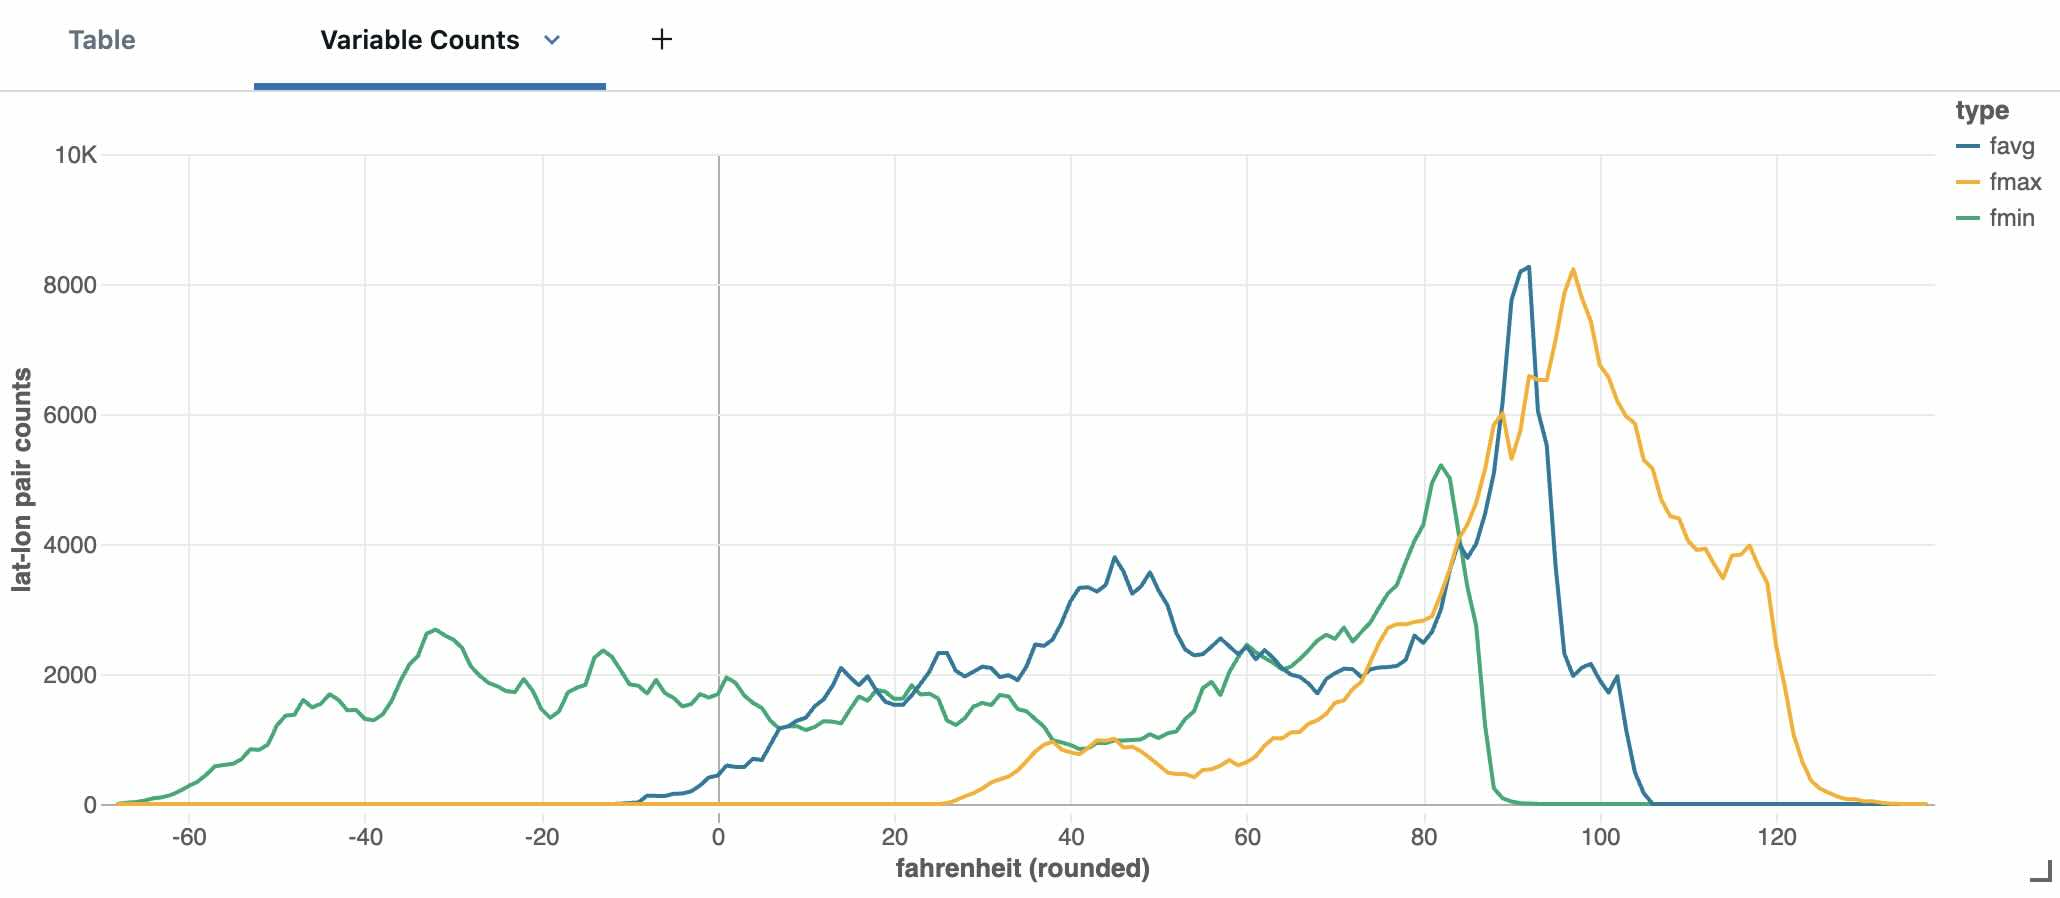

In [0]:
displayHTML("""<img src="..." width="75%">""")

_Run the following in Databricks to render the chart._

In [0]:
# display(
#   df_agg_2025.drop("all_days").groupBy("fmin").count().withColumn("type", F.lit("fmin"))
#   .union(
#     df_agg_2025.drop("all_days").groupBy("fmax").count().withColumn("type", F.lit("fmax"))
#   )
#   .union(
#     df_agg_2025.drop("all_days").groupBy("favg").count().withColumn("type", F.lit("favg"))
#   )
# )

## Include 2050 SSP245 Model [Moderate]

> Now that we understand the 2025 model, let's add the 2050 model and compare the two.

In [0]:
filename_2050 = "tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2050.nc"
os.environ['FILENAME_2050'] = filename_2050

In [0]:
%sh
wget -P $VOL_DIR -nc https://nex-gddp-cmip6.s3-us-west-2.amazonaws.com/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/tasmax/$FILENAME_2050
ls -lh $VOL_DIR

File ‘/Volumes/geospatial_docs/large_netcdf/data/tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2050.nc’ already there; not retrieving.



total 466M
-rwxrwxrwx 1 nobody nogroup 233M Oct 12 14:04 tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2025.nc
-rwxrwxrwx 1 nobody nogroup 233M Feb  7 12:21 tasmax_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2050.nc


_Set `drop_table=False` to now append 2050 to the 'xy_pred_annual' table._

In [0]:
df_all = process_annual(
  f'{vol_dir}/{filename_2050}',
  'tasmax', 'xy_pred_annual', vol_dir_out, drop_table=False, debug_mode=1
)

... n_lat: 600
... total batches estimated: 600
... finished batch(es) per lat
... rows in table? 1,726,800


data_var,year,lat,lon,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31,day_32,day_33,day_34,day_35,day_36,day_37,day_38,day_39,day_40,day_41,day_42,day_43,day_44,day_45,day_46,day_47,day_48,day_49,day_50,day_51,day_52,day_53,day_54,day_55,day_56,day_57,day_58,day_59,day_60,day_61,day_62,day_63,day_64,day_65,day_66,day_67,day_68,day_69,day_70,day_71,day_72,day_73,day_74,day_75,day_76,day_77,day_78,day_79,day_80,day_81,day_82,day_83,day_84,day_85,day_86,day_87,day_88,day_89,day_90,day_91,day_92,day_93,day_94,day_95,day_96,day_97,day_98,day_99,day_100,day_101,day_102,day_103,day_104,day_105,day_106,day_107,day_108,day_109,day_110,day_111,day_112,day_113,day_114,day_115,day_116,day_117,day_118,day_119,day_120,day_121,day_122,day_123,day_124,day_125,day_126,day_127,day_128,day_129,day_130,day_131,day_132,day_133,day_134,day_135,day_136,day_137,day_138,day_139,day_140,day_141,day_142,day_143,day_144,day_145,day_146,day_147,day_148,day_149,day_150,day_151,day_152,day_153,day_154,day_155,day_156,day_157,day_158,day_159,day_160,day_161,day_162,day_163,day_164,day_165,day_166,day_167,day_168,day_169,day_170,day_171,day_172,day_173,day_174,day_175,day_176,day_177,day_178,day_179,day_180,day_181,day_182,day_183,day_184,day_185,day_186,day_187,day_188,day_189,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199,day_200,day_201,day_202,day_203,day_204,day_205,day_206,day_207,day_208,day_209,day_210,day_211,day_212,day_213,day_214,day_215,day_216,day_217,day_218,day_219,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229,day_230,day_231,day_232,day_233,day_234,day_235,day_236,day_237,day_238,day_239,day_240,day_241,day_242,day_243,day_244,day_245,day_246,day_247,day_248,day_249,day_250,day_251,day_252,day_253,day_254,day_255,day_256,day_257,day_258,day_259,day_260,day_261,day_262,day_263,day_264,day_265,day_266,day_267,day_268,day_269,day_270,day_271,day_272,day_273,day_274,day_275,day_276,day_277,day_278,day_279,day_280,day_281,day_282,day_283,day_284,day_285,day_286,day_287,day_288,day_289,day_290,day_291,day_292,day_293,day_294,day_295,day_296,day_297,day_298,day_299,day_300,day_301,day_302,day_303,day_304,day_305,day_306,day_307,day_308,day_309,day_310,day_311,day_312,day_313,day_314,day_315,day_316,day_317,day_318,day_319,day_320,day_321,day_322,day_323,day_324,day_325,day_326,day_327,day_328,day_329,day_330,day_331,day_332,day_333,day_334,day_335,day_336,day_337,day_338,day_339,day_340,day_341,day_342,day_343,day_344,day_345,day_346,day_347,day_348,day_349,day_350,day_351,day_352,day_353,day_354,day_355,day_356,day_357,day_358,day_359,day_360,day_361,day_362,day_363,day_364,day_365
tasmax,2025,-59.875,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [0]:
%sql select format_number(count(1),0) as count from xy_pred_annual where year=2050

count
"863,400"


## Compare Models

> 2025 and 2050 daily model values for tasmax. This will be a difference chart. 

In [0]:
df_agg = (
  spark.table("xy_pred_annual")
    .withColumn("all_days", F.array(*day_cols))
    .selectExpr(f"* except({', '.join(day_cols)})")
    .withColumn("kmax", F.array_max("all_days"))
    .filter("kmax > 0")
    .withColumn("kmin", F.array_min("all_days"))
    .withColumn("kavg", F.expr("aggregate(all_days, 0D, (acc, x) -> acc + x) / size(all_days)"))
    .withColumn("fmin", (F.col("kmin") - 273.15) * 9/5 + 32)
    .withColumn("fmax", (F.col("kmax") - 273.15) * 9/5 + 32)
    .withColumn("favg", (F.col("kavg") - 273.15) * 9/5 + 32)
    .drop("all_days")     
  .groupBy("data_var", "year", "lat", "lon")
  .agg(F.avg("fmin").alias("fmin"), F.avg("fmax").alias("fmax"), F.avg("favg").alias("favg"))                  
)
df_agg.limit(1).show(vertical=True)

-RECORD 0-----------------------
 data_var | tasmax              
 year     | 2050                
 lat      | 68.375              
 lon      | 78.375              
 fmin     | -21.774315999999928 
 fmax     | 88.98112400000001   
 favg     | 31.72521066849289   



In [0]:
from pyspark.sql import Window

window = Window.partitionBy("data_var", "lat", "lon").orderBy("year")

df_comp = (
  df_agg
    .withColumn(
      "fmin_2050",
      F.lead("fmin", 1).over(window)
    )
    .withColumn(
      "fmax_2050",
      F.lead("fmax", 1).over(window)
    )
    .withColumn(
      "favg_2050",
      F.lead("favg", 1).over(window)
    )
    .filter("year = 2025")
    .withColumn("fmin_diff", F.expr("fmin_2050 - fmin"))
    .withColumn("fmax_diff", F.expr("fmax_2050 - fmax"))
    .withColumn("favg_diff", F.expr("favg_2050 - favg"))
)
df_comp.limit(5).display()

data_var,year,lat,lon,fmin,fmax,favg,fmin_2050,fmax_2050,favg_2050,fmin_diff,fmax_diff,favg_diff
tasmax,2025,-56.375,332.375,20.200892000000056,39.80598799999999,33.66663804931518,24.896786000000077,41.394830000000034,35.04253136986333,4.69589400000002,1.5888420000000423,1.3758933205481512
tasmax,2025,-55.875,292.375,31.00886600000008,62.877344000000036,47.98268456986257,33.62277200000002,60.014354000000026,47.77684317808232,2.6139059999999397,-2.8629900000000106,-0.20584139178024685
tasmax,2025,-55.875,292.625,31.327520000000085,62.820428000000085,48.04049494794539,33.59109199999999,60.452420000000075,47.85324652054849,2.263571999999904,-2.3680080000000103,-0.18724842739690217
tasmax,2025,-55.875,292.875,31.704260000000055,62.75534000000009,48.10389316712339,33.59750000000008,60.830690000000075,47.935233956164645,1.8932400000000271,-1.924650000000014,-0.1686592109587437
tasmax,2025,-55.625,290.875,28.68540800000004,61.539476,45.12145585753378,32.467640000000074,57.167132,44.82993846027424,3.7822320000000325,-4.372343999999998,-0.29151739725953973


_Negative means cooler in 2050, positive means warmer._

> We are rounding the diff to the nearest integer for display purposes.


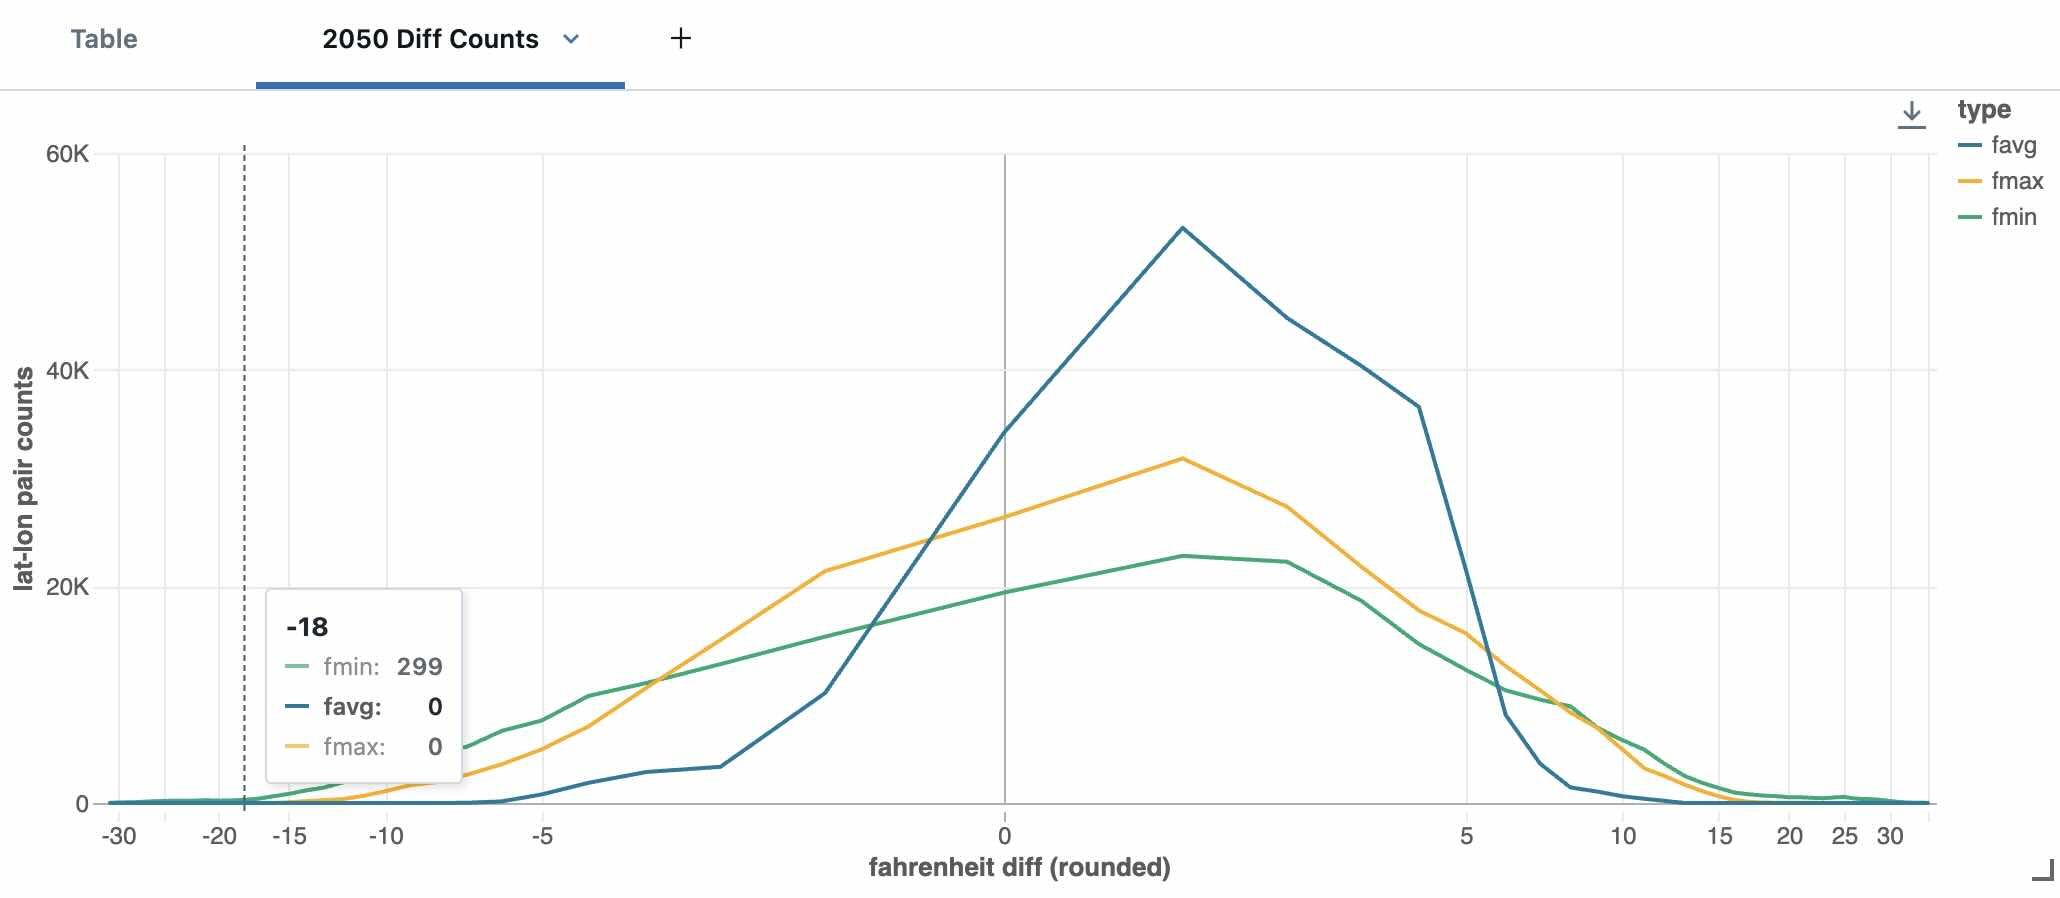

In [0]:
displayHTML("""<img src="..." width="75%">""")

_Run the following in Databricks to render the chart._

In [0]:
# display(
#   df_comp.groupBy(F.round("fmin_diff").alias("rnd_fmin_diff")).count().withColumn("type", F.lit("fmin"))
#   .union(
#     df_comp.groupBy(F.round("fmax_diff").alias("rnd_fmax_diff")).count().withColumn("type", F.lit("fmax"))
#   )
#   .union(
#     df_comp.groupBy(F.round("favg_diff").alias("rnd_favg_diff")).count().withColumn("type", F.lit("favg"))
#   )
# )